<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/ANN_DL_PRJ_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Image Classification — AneRBC Dataset
**Name:** \<Your Name\>
**SRN:** \<Your SRN\>

Custom CNNs (3/4/5 layers), Transfer Learning, and Explainable AI (Grad-CAM) for blood smear anemia classification.


In [ ]:
# Name: <NIMRA SAEED>
# SRN: <303231009>
# Project: Medical Image Classification - AneRBC Dataset


## Task 0: Setup — Drive & Git

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cpu


## Task 1: Loading & Cleaning the Dataset

### 1.1 Dataset location

Dataset manually downloaded and placed in Google Drive (see README for source link / download instructions).

In [ ]:
BASE_PATH = "/content/drive/MyDrive/anerbc_dataset/  AneRBC dataset/AneRBC_dataset"

paths = [
    ("AneRBC-I/Anemic_individuals/Original_images", 0),
    ("AneRBC-I/Healthy_individuals/Original_images", 1),
    ("AneRBC-II/Anemic_individuals/Original_images", 0),
    ("AneRBC-II/Healthy_individuals/Original_images", 1),
]


### 1.2 Data validation: corrupted files, label mapping, class distribution

Total valid images: 13000
Corrupted/unreadable images: 0
Class 0 (Anemic): 6500 images
Class 1 (Healthy): 6500 images


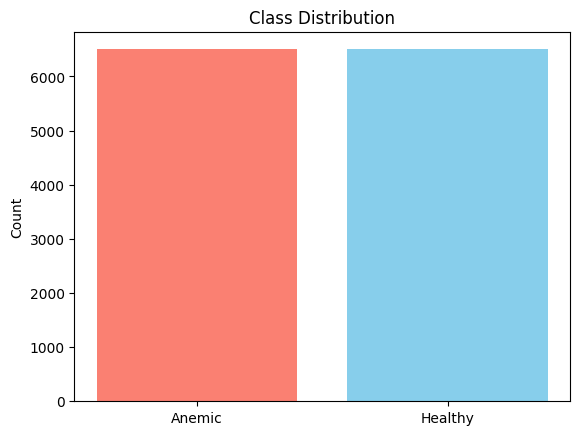

In [ ]:
def validate_and_collect(base_path, paths):
    """
    Validate images and collect file paths with labels.

    Args:
        base_path (str): root dataset directory.
        paths (list[tuple]): list of (subfolder, label) pairs.

    Returns:
        data (list[str]): valid image file paths.
        labels (list[int]): corresponding labels.
        corrupted (list[str]): paths that failed to load.

    Assumes: subfolders exist under base_path; images are readable by OpenCV.
    """
    data, labels, corrupted = [], [], []

    for sub_path, label in paths:
        full_path = os.path.join(base_path, sub_path)
        if not os.path.exists(full_path):
            print("Missing folder:", full_path)
            continue

        for fname in os.listdir(full_path):
            fpath = os.path.join(full_path, fname)
            if not os.path.isfile(fpath):
                continue
            img = cv2.imread(fpath)
            if img is None or img.size == 0:
                corrupted.append(fpath)
                continue
            data.append(fpath)
            labels.append(label)

    return data, labels, corrupted

data, labels, corrupted = validate_and_collect(BASE_PATH, paths)

print("Total valid images:", len(data))
print("Corrupted/unreadable images:", len(corrupted))
for c in corrupted[:10]:
    print(" -", c)

class_map = {0: "Anemic", 1: "Healthy"}
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Class {u} ({class_map[u]}): {c} images")

plt.bar([class_map[u] for u in unique], counts, color=["salmon", "skyblue"])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()


### 1.3 Preprocessing pipeline (resize + normalization)

In [ ]:
IMG_SIZE = 128

# Normalize with ImageNet stats so pretrained models (Task 3) also work consistently
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])


In [ ]:
class RBCDataset(Dataset):
    """
    PyTorch Dataset for AneRBC blood smear images.

    Args:
        image_paths (list[str]): paths to validated image files.
        labels (list[int]): integer class labels.
        transform (callable): torchvision transform pipeline.

    Assumes all paths have already been validated (no corrupted files).
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


### 1.4 Stratified train/val/test split + dataloaders (deterministic seed)

In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    data, labels, test_size=0.3, stratify=labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED
)

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}, Test: {len(test_paths)}")

train_dataset = RBCDataset(train_paths, train_labels, transform=transform)
val_dataset   = RBCDataset(val_paths, val_labels, transform=transform)
test_dataset  = RBCDataset(test_paths, test_labels, transform=transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Train: 9100, Val: 1950, Test: 1950


### 1.5 Commit & push

In [ ]:
%%writefile .gitignore
drive/
data/raw/
*.jpg
*.jpeg
*.png
*.bmp
*.tif
__pycache__/
.ipynb_checkpoints/

Overwriting .gitignore


In [ ]:
# Remove the accidentally-tracked Drive/image files from git's index (keeps the actual files, just untracks them)
!git rm -r --cached drive 2>/dev/null
!git status

On branch master
nothing to commit, working tree clean


In [ ]:
!git add .
!git commit -m "Task1: data validation, preprocessing, stratified train/val/test split"
!git push


On branch master
nothing to commit, working tree clean
fatal: The current branch master has no upstream branch.
To push the current branch and set the remote as upstream, use

    git push --set-upstream origin master



In [ ]:
!git push -u origin master

Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 2 threads
Compressing objects: 100% (22/22), done.
Writing objects: 100% (29/29), 8.42 MiB | 1.29 MiB/s, done.
Total 29 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), done.
remote: 
remote: Create a pull request for 'master' on GitHub by visiting:
remote:      https://github.com/nimraa9090/ANN-DL-PRJ/pull/new/master
remote: 
To https://github.com/nimraa9090/ANN-DL-PRJ
 * [new branch]      master -> master
Branch 'master' set up to track remote branch 'master' from 'origin'.


## Task 2: Custom Deep CNN (3, 4, and 5 layers)

### 2.1 Model architectures

In [ ]:
class CNN3Layer(nn.Module):
    """3 conv-block CNN: Conv-ReLU-Pool x3 + FC head with dropout."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64*16*16, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class CNN4Layer(nn.Module):
    """4 conv-block CNN."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128*8*8, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


class CNN5Layer(nn.Module):
    """5 conv-block CNN."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256*4*4, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


### 2.2 Train & validate (with learning curves)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """
    Train a model, tracking train/val loss per epoch.

    Args:
        model (nn.Module): model to train.
        train_loader, val_loader (DataLoader): data loaders.
        epochs (int): number of training epochs.
        lr (float): learning rate for Adam optimizer.

    Returns:
        model (nn.Module): trained model.
        history (dict): train_loss and val_loss per epoch.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_loss = total_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                val_loss += criterion(out, y).item()
        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return model, history


def plot_learning_curve(history, title):
    """Plot train vs val loss curves."""
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title); plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.show()


### 2.3 Test, evaluate (precision/recall/F1, classification report, confusion matrix)


===== Training CNN3 =====
Epoch 1/10 | Train Loss: 0.6882 | Val Loss: 0.6973
Epoch 2/10 | Train Loss: 0.6835 | Val Loss: 0.6888
Epoch 3/10 | Train Loss: 0.6749 | Val Loss: 0.6717
Epoch 4/10 | Train Loss: 0.6354 | Val Loss: 0.6774
Epoch 5/10 | Train Loss: 0.6021 | Val Loss: 0.5593
Epoch 6/10 | Train Loss: 0.5576 | Val Loss: 0.5397
Epoch 7/10 | Train Loss: 0.4881 | Val Loss: 0.5087
Epoch 8/10 | Train Loss: 0.4396 | Val Loss: 0.4246
Epoch 9/10 | Train Loss: 0.3776 | Val Loss: 0.4163
Epoch 10/10 | Train Loss: 0.3341 | Val Loss: 0.4717


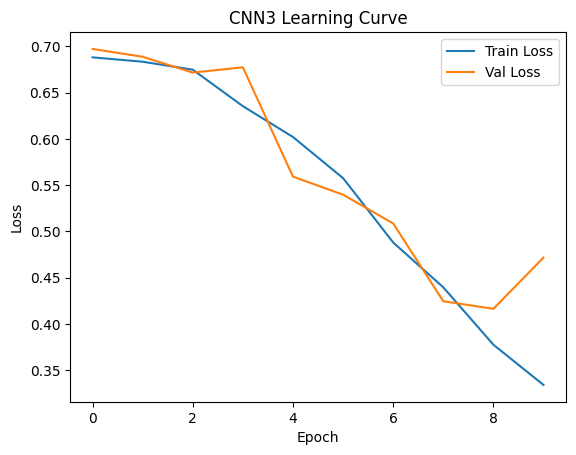

Accuracy: 0.7717948717948718
              precision    recall  f1-score   support

      Anemic       0.70      0.94      0.80       975
     Healthy       0.91      0.60      0.73       975

    accuracy                           0.77      1950
   macro avg       0.81      0.77      0.77      1950
weighted avg       0.81      0.77      0.77      1950



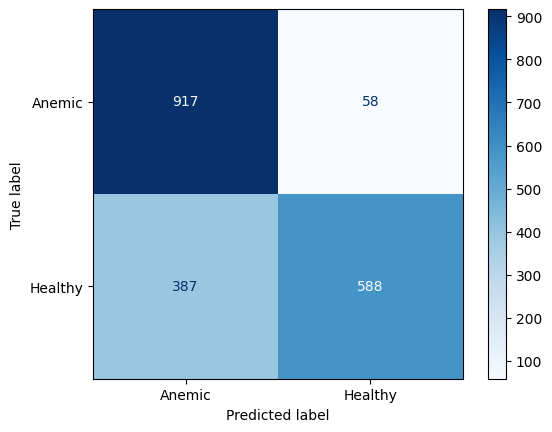


===== Training CNN4 =====
Epoch 1/10 | Train Loss: 0.6939 | Val Loss: 0.6932
Epoch 2/10 | Train Loss: 0.6931 | Val Loss: 0.6917
Epoch 3/10 | Train Loss: 0.6925 | Val Loss: 0.6909
Epoch 4/10 | Train Loss: 0.6909 | Val Loss: 0.6914
Epoch 5/10 | Train Loss: 0.6871 | Val Loss: 0.6904
Epoch 6/10 | Train Loss: 0.6867 | Val Loss: 0.6881
Epoch 7/10 | Train Loss: 0.6612 | Val Loss: 0.6567
Epoch 8/10 | Train Loss: 0.6686 | Val Loss: 0.6817
Epoch 9/10 | Train Loss: 0.6291 | Val Loss: 0.6463
Epoch 10/10 | Train Loss: 0.6008 | Val Loss: 0.6025


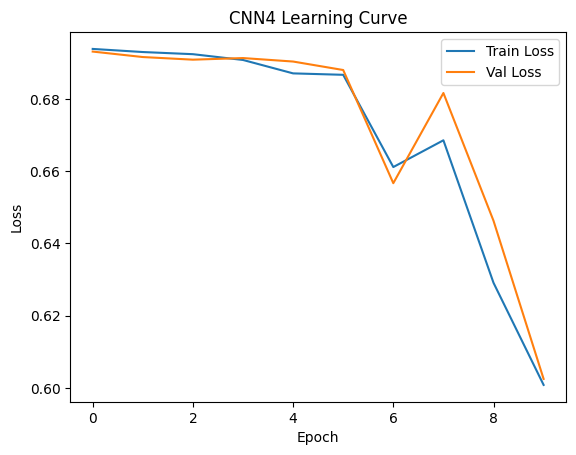

Accuracy: 0.6446153846153846
              precision    recall  f1-score   support

      Anemic       0.61      0.79      0.69       975
     Healthy       0.70      0.50      0.59       975

    accuracy                           0.64      1950
   macro avg       0.66      0.64      0.64      1950
weighted avg       0.66      0.64      0.64      1950



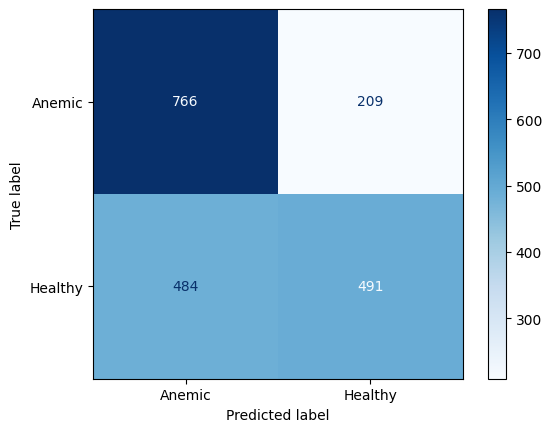


===== Training CNN5 =====
Epoch 1/10 | Train Loss: 0.6948 | Val Loss: 0.6929
Epoch 2/10 | Train Loss: 0.6928 | Val Loss: 0.6936
Epoch 3/10 | Train Loss: 0.6919 | Val Loss: 0.6923
Epoch 4/10 | Train Loss: 0.6922 | Val Loss: 0.7011
Epoch 5/10 | Train Loss: 0.6921 | Val Loss: 0.6919
Epoch 6/10 | Train Loss: 0.6897 | Val Loss: 0.6884
Epoch 7/10 | Train Loss: 0.6715 | Val Loss: 0.6094
Epoch 8/10 | Train Loss: 0.5903 | Val Loss: 0.5517
Epoch 9/10 | Train Loss: 0.5530 | Val Loss: 0.5861
Epoch 10/10 | Train Loss: 0.5124 | Val Loss: 0.5034


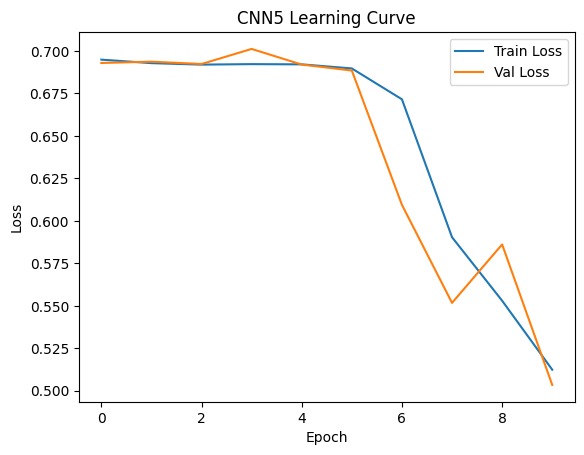

Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

      Anemic       0.75      0.81      0.78       975
     Healthy       0.80      0.72      0.76       975

    accuracy                           0.77      1950
   macro avg       0.77      0.77      0.77      1950
weighted avg       0.77      0.77      0.77      1950



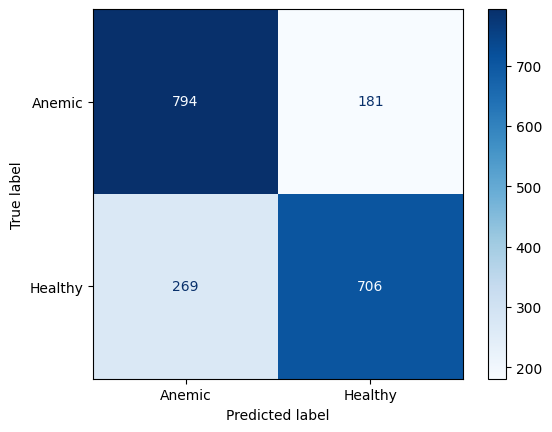

Best custom model: CNN3


In [ ]:
def evaluate_model(model, loader, class_names=("Anemic", "Healthy")):
    """
    Evaluate a trained model on a data loader.

    Args:
        model (nn.Module): trained model.
        loader (DataLoader): evaluation data loader.
        class_names (tuple): display names for classes.

    Returns:
        acc (float): accuracy score. Also prints classification report
        and plots a confusion matrix.
    """
    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            _, p = torch.max(out, 1)
            preds.extend(p.cpu().numpy())
            true.extend(y.numpy())

    acc = accuracy_score(true, preds)
    print("Accuracy:", acc)
    print(classification_report(true, preds, target_names=class_names))

    cm = confusion_matrix(true, preds)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")
    plt.show()
    return acc


results = {}
for name, ModelClass in [("CNN3", CNN3Layer), ("CNN4", CNN4Layer), ("CNN5", CNN5Layer)]:
    print(f"\n===== Training {name} =====")
    model = ModelClass()
    model, history = train_model(model, train_loader, val_loader, epochs=10)
    plot_learning_curve(history, f"{name} Learning Curve")
    acc = evaluate_model(model, test_loader)
    results[name] = {"model": model, "acc": acc}

best_custom_name = max(results, key=lambda k: results[k]["acc"])
best_custom_model = results[best_custom_name]["model"]
print("Best custom model:", best_custom_name)


In [ ]:
import os, shutil

# Save checkpoints locally
os.makedirs("checkpoints", exist_ok=True)
for name, info in results.items():
    torch.save(info["model"].state_dict(), f"checkpoints/{name}.pt")
    print("Saved locally:", name)

# Backup to Drive (survives disconnects)
os.makedirs("/content/drive/MyDrive/anerbc_checkpoints", exist_ok=True)
for name in results.keys():
    shutil.copy(f"checkpoints/{name}.pt", f"/content/drive/MyDrive/anerbc_checkpoints/{name}.pt")
    print("Backed up to Drive:", name)

# Commit and push
!git add .
!git commit -m "Task2: 3/4/5-layer CNNs trained and evaluated, checkpoints saved"
!git push

Saved locally: CNN3
Saved locally: CNN4
Saved locally: CNN5
Backed up to Drive: CNN3
Backed up to Drive: CNN4
Backed up to Drive: CNN5
[master 561177b] Task2: 3/4/5-layer CNNs trained and evaluated, checkpoints saved
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 checkpoints/CNN3.pt
 create mode 100644 checkpoints/CNN4.pt
 create mode 100644 checkpoints/CNN5.pt
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 14.85 MiB | 10.24 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/nimraa9090/ANN-DL-PRJ
   a41181f..561177b  master -> master


### 2.4 Commit & push

In [ ]:
!git add .
!git commit -m "Task2: 3/4/5-layer CNNs trained and evaluated"
!git push


On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean
Everything up-to-date


## Task 3: Pretrained CNNs (MobileNet, ResNet, DenseNet) — Fine-tune Top Layers

Backbone is frozen; only the new classifier head is trainable (documented per model below).


===== mobilenet =====
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 105MB/s] 


Epoch 1/5 | Train Loss: 0.4984 | Val Loss: 0.4166
Epoch 2/5 | Train Loss: 0.4666 | Val Loss: 0.3955
Epoch 3/5 | Train Loss: 0.4592 | Val Loss: 0.4073
Epoch 4/5 | Train Loss: 0.4517 | Val Loss: 0.3920
Epoch 5/5 | Train Loss: 0.4500 | Val Loss: 0.4247


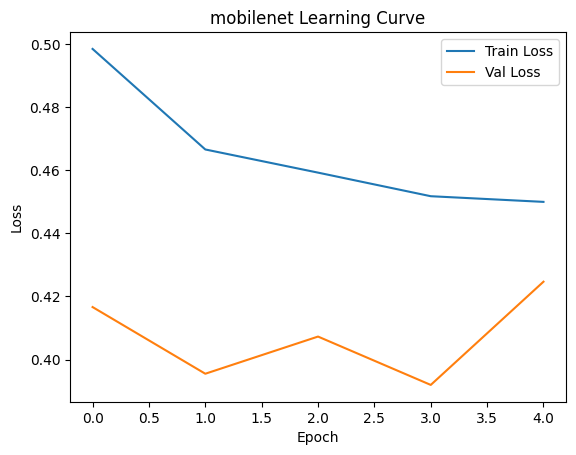

Accuracy: 0.8179487179487179
              precision    recall  f1-score   support

      Anemic       0.93      0.69      0.79       975
     Healthy       0.75      0.95      0.84       975

    accuracy                           0.82      1950
   macro avg       0.84      0.82      0.81      1950
weighted avg       0.84      0.82      0.81      1950



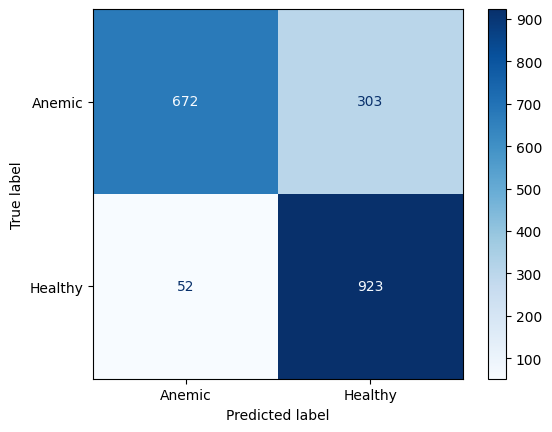


===== resnet =====
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 141MB/s]


Epoch 1/5 | Train Loss: 0.5265 | Val Loss: 0.4716
Epoch 2/5 | Train Loss: 0.4725 | Val Loss: 0.4372
Epoch 3/5 | Train Loss: 0.4656 | Val Loss: 0.4410
Epoch 4/5 | Train Loss: 0.4602 | Val Loss: 0.4326
Epoch 5/5 | Train Loss: 0.4532 | Val Loss: 0.4227


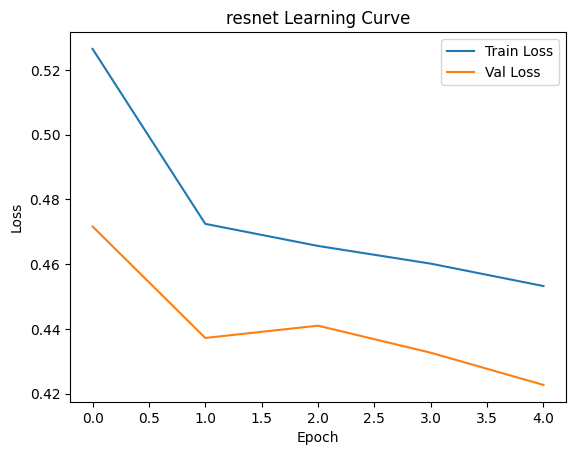

Accuracy: 0.8046153846153846
              precision    recall  f1-score   support

      Anemic       0.84      0.75      0.79       975
     Healthy       0.78      0.86      0.81       975

    accuracy                           0.80      1950
   macro avg       0.81      0.80      0.80      1950
weighted avg       0.81      0.80      0.80      1950



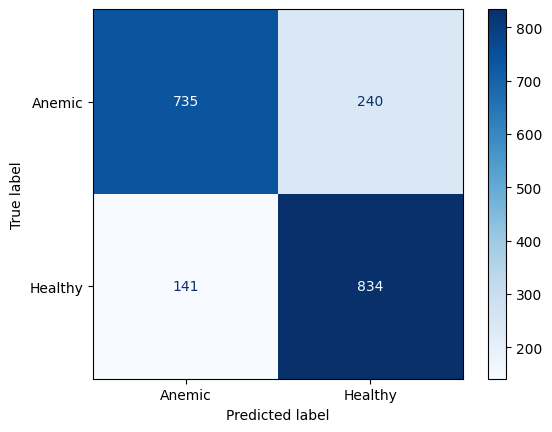


===== densenet =====
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 142MB/s]


Epoch 1/5 | Train Loss: 0.5001 | Val Loss: 0.4496
Epoch 2/5 | Train Loss: 0.4474 | Val Loss: 0.4199
Epoch 3/5 | Train Loss: 0.4397 | Val Loss: 0.4510
Epoch 4/5 | Train Loss: 0.4246 | Val Loss: 0.4067
Epoch 5/5 | Train Loss: 0.4328 | Val Loss: 0.4097


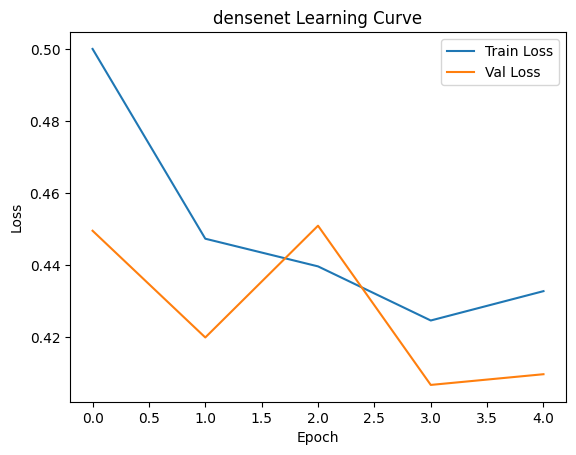

Accuracy: 0.8266666666666667
              precision    recall  f1-score   support

      Anemic       0.89      0.75      0.81       975
     Healthy       0.78      0.91      0.84       975

    accuracy                           0.83      1950
   macro avg       0.84      0.83      0.83      1950
weighted avg       0.84      0.83      0.83      1950



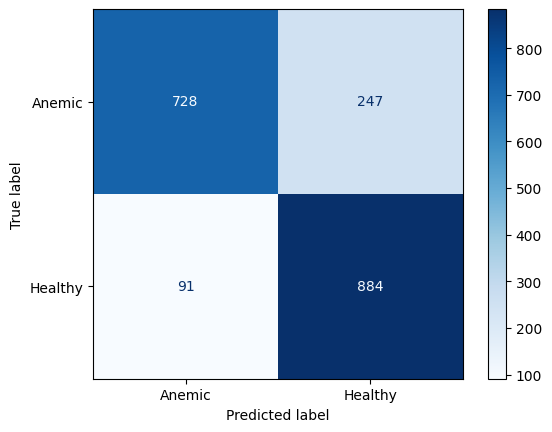

Best pretrained model: densenet


In [ ]:
import torchvision.models as models

def build_transfer_model(name, num_classes=2):
    """
    Loads a pretrained backbone, freezes it, replaces the classifier head.

    Args:
        name (str): one of "mobilenet", "resnet", "densenet".
        num_classes (int): number of output classes.

    Returns:
        nn.Module with frozen backbone and a new trainable head.
    """
    if name == "mobilenet":
        m = models.mobilenet_v2(weights="IMAGENET1K_V1")
        for p in m.parameters(): p.requires_grad = False
        m.classifier[1] = nn.Linear(m.last_channel, num_classes)  # trainable
    elif name == "resnet":
        m = models.resnet18(weights="IMAGENET1K_V1")
        for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Linear(m.fc.in_features, num_classes)  # trainable
    elif name == "densenet":
        m = models.densenet121(weights="IMAGENET1K_V1")
        for p in m.parameters(): p.requires_grad = False
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)  # trainable
    else:
        raise ValueError(name)
    return m


transfer_results = {}
for name in ["mobilenet", "resnet", "densenet"]:
    print(f"\n===== {name} =====")
    tmodel = build_transfer_model(name)
    tmodel, hist = train_model(tmodel, train_loader, val_loader, epochs=5, lr=1e-3)
    plot_learning_curve(hist, f"{name} Learning Curve")
    acc = evaluate_model(tmodel, test_loader)
    transfer_results[name] = {"model": tmodel, "acc": acc}

best_pretrained_name = max(transfer_results, key=lambda k: transfer_results[k]["acc"])
best_pretrained_model = transfer_results[best_pretrained_name]["model"]
print("Best pretrained model:", best_pretrained_name)


In [ ]:
import os, shutil

# Save checkpoints locally
os.makedirs("checkpoints", exist_ok=True)
for name, info in transfer_results.items():
    torch.save(info["model"].state_dict(), f"checkpoints/{name}.pt")
    print("Saved locally:", name)

# Backup to Drive (survives disconnects)
os.makedirs("/content/drive/MyDrive/anerbc_checkpoints", exist_ok=True)
for name in transfer_results.keys():
    shutil.copy(f"checkpoints/{name}.pt", f"/content/drive/MyDrive/anerbc_checkpoints/{name}.pt")
    print("Backed up to Drive:", name)

# Commit and push
!git add .
!git commit -m "Task3: transfer learning with MobileNet, ResNet, DenseNet trained and evaluated, checkpoints saved"
!git push

Saved locally: mobilenet
Saved locally: resnet
Saved locally: densenet
Backed up to Drive: mobilenet
Backed up to Drive: resnet
Backed up to Drive: densenet
[master a41181f] Task3: transfer learning with MobileNet, ResNet, DenseNet trained and evaluated, checkpoints saved
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 checkpoints/densenet.pt
 create mode 100644 checkpoints/mobilenet.pt
 create mode 100644 checkpoints/resnet.pt
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 72.87 MiB | 10.04 MiB/s, done.
Total 6 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/nimraa9090/ANN-DL-PRJ
   d6360a7..a41181f  master -> master


### Commit & push

In [ ]:
!git add .
!git commit -m "Task3: transfer learning with MobileNet, ResNet, DenseNet (frozen backbone, trained head)"
!git push


On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean
Everything up-to-date


## Task 4: XAI — Grad-CAM on Best Custom + Best Pretrained Model

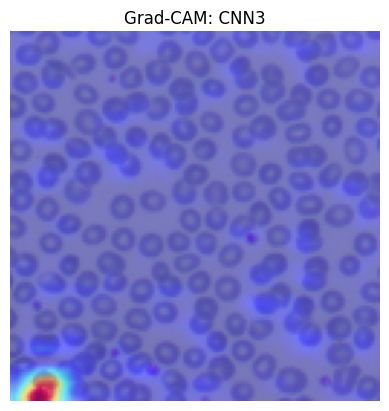

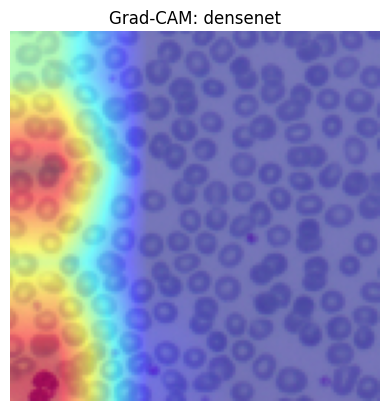

In [ ]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def run_gradcam(model, target_layer, image_tensor, orig_img_rgb):
    """
    Run Grad-CAM on a single image and overlay the heatmap.

    Args:
        model (nn.Module): trained model.
        target_layer (nn.Module): convolutional layer to visualize.
        image_tensor (Tensor): preprocessed input tensor (C,H,W).
        orig_img_rgb (np.ndarray): original RGB image resized to IMG_SIZE (H,W,3), uint8.

    Returns:
        np.ndarray: RGB image with Grad-CAM heatmap overlay.
    """
    input_tensor = image_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)   # force gradient tracking even with frozen backbone

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    vis = show_cam_on_image(orig_img_rgb / 255.0, grayscale_cam, use_rgb=True)
    return vis

# Pick one test sample
sample_path = test_paths[0]
raw = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
raw_resized = cv2.resize(raw, (IMG_SIZE, IMG_SIZE))
inp = transform(raw_resized)

# Custom CNN: last conv layer in the feature extractor
cam_custom = run_gradcam(best_custom_model, best_custom_model.features[-3], inp, raw_resized)
plt.imshow(cam_custom); plt.title(f"Grad-CAM: {best_custom_name}"); plt.axis("off"); plt.show()

# Pretrained: last conv layer (adjust attribute per architecture)
if best_pretrained_name == "resnet":
    target_layer = best_pretrained_model.layer4[-1]
else:
    target_layer = best_pretrained_model.features[-1]

cam_pretrained = run_gradcam(best_pretrained_model, target_layer, inp, raw_resized)
plt.imshow(cam_pretrained); plt.title(f"Grad-CAM: {best_pretrained_name}"); plt.axis("off"); plt.show()

### Commit & push

In [ ]:
%%writefile .gitignore
drive/
data/raw/
__pycache__/
.ipynb_checkpoints/

Overwriting .gitignore


In [ ]:
import cv2

cv2.imwrite("checkpoints/gradcam_custom.png", cv2.cvtColor(cam_custom, cv2.COLOR_RGB2BGR))
cv2.imwrite("checkpoints/gradcam_pretrained.png", cv2.cvtColor(cam_pretrained, cv2.COLOR_RGB2BGR))

!git add .
!git commit -m "Task4: Grad-CAM XAI outputs saved"
!git push

[master 36c2e0e] Task4: Grad-CAM XAI outputs saved
 3 files changed, 5 deletions(-)
 create mode 100644 checkpoints/gradcam_custom.png
 create mode 100644 checkpoints/gradcam_pretrained.png
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 60.17 KiB | 12.03 MiB/s, done.
Total 6 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/nimraa9090/ANN-DL-PRJ
   561177b..36c2e0e  master -> master


In [ ]:
!git add .
!git commit -m "Task4: Grad-CAM XAI on best custom and pretrained models"
!git push


On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean
Everything up-to-date


In [ ]:
!git log --oneline

36c2e0e (HEAD -> master, origin/master) Task4: Grad-CAM XAI outputs saved
561177b Task2: 3/4/5-layer CNNs trained and evaluated, checkpoints saved
a41181f Task3: transfer learning with MobileNet, ResNet, DenseNet trained and evaluated, checkpoints saved
d6360a7 Task1: data validation, preprocessing, stratified train/val/test split


## Task 5 (separate deliverable)
Write the ≤5000-word critical evaluation report and `README.md` separately and submit/commit them
alongside this notebook (see assignment brief, Task 5).

In [ ]:
%%writefile README.md
   <# Medical Image Classification — AneRBC Dataset

Custom CNNs (3/4/5 layers), Transfer Learning (MobileNetV2, ResNet18, DenseNet121), and Explainable AI (Grad-CAM) for blood smear anemia classification (Anemic vs Healthy).

**Name:** <Your Name>
**SRN:** <Your SRN>

---

## 1. Environment Setup

This project was developed and run on **Google Colab**.

### Requirements
- Python 3.10+
- PyTorch + torchvision
- OpenCV (`opencv-python`)
- numpy, pandas, matplotlib
- scikit-learn
- `grad-cam` (Captum-style Grad-CAM implementation for PyTorch)

### Installing dependencies
If running outside Colab (e.g. locally or on Kaggle), install with:

```bash
pip install torch torchvision opencv-python numpy pandas matplotlib scikit-learn grad-cam
```

On Colab, only the XAI library needs manual installation (everything else is preinstalled):

```python
!pip install grad-cam -q
```

### GitHub authentication (for contributors)
Do **not** hardcode a GitHub token in any notebook cell. Use Colab's Secrets manager:
1. Click the 🔑 key icon in the left sidebar of Colab
2. Add a secret named `GITHUB_PAT` with your personal access token as the value
3. Enable notebook access for the secret

The setup cell reads it via:
```python
from google.colab import userdata
GITHUB_PAT = userdata.get('GITHUB_PAT')
```

---

## 2. Dataset Setup

**Dataset:** AneRBC (Macroscopic Blood Smear Cell Image Dataset)
**Classes:** Anemic (0), Healthy (1)

### Download / prepare
1. Download the AneRBC dataset from its original source (see report for citation/link).
2. Place it in your Google Drive under:
   ```
   MyDrive/anerbc_dataset/AneRBC dataset/AneRBC_dataset/
   ├── AneRBC-I/
   │   ├── Anemic_individuals/Original_images/
   │   └── Healthy_individuals/Original_images/
   └── AneRBC-II/
       ├── Anemic_individuals/Original_images/
       └── Healthy_individuals/Original_images/
   ```
3. Mount Drive in Colab:
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   ```
4. Update `BASE_PATH` in the notebook if your folder name/path differs.

The dataset itself is **not stored in this Git repository** (excluded via `.gitignore`) — only code, trained model checkpoints, and XAI outputs are version-controlled.

---

## 3. Project Structure

```
.
├── ANN_DL_PRJ_Solution.ipynb   # Main notebook (Tasks 1-4)
├── checkpoints/                 # Saved model weights (.pt) and Grad-CAM outputs (.png)
├── README.md
└── .gitignore
```

---

## 4. How to Train Each Model Family

Open `ANN_DL_PRJ_Solution.ipynb` in Google Colab and run cells **top to bottom**.

### Task 1 — Data preparation
Runs validation (corruption checks, class distribution), preprocessing (resize to 128x128, ImageNet normalization), and a stratified train/val/test split (seed=42).

### Task 2 — Custom CNNs
Trains three custom architectures (`CNN3Layer`, `CNN4Layer`, `CNN5Layer`) for 10 epochs each (Adam optimizer, lr=1e-3, CrossEntropyLoss). Each model's weights are saved to `checkpoints/<name>.pt` after training.

```python
results = {}
for name, ModelClass in [("CNN3", CNN3Layer), ("CNN4", CNN4Layer), ("CNN5", CNN5Layer)]:
    model = ModelClass()
    model, history = train_model(model, train_loader, val_loader, epochs=10)
    ...
```

### Task 3 — Transfer learning
Fine-tunes the classifier head of three pretrained backbones (MobileNetV2, ResNet18, DenseNet121) with the backbone frozen. Trainable layers are documented inline in `build_transfer_model()`.

```python
for name in ["mobilenet", "resnet", "densenet"]:
    tmodel = build_transfer_model(name)
    tmodel, hist = train_model(tmodel, train_loader, val_loader, epochs=5)
    ...
```

**Note:** training time is significantly faster with a GPU runtime (Runtime → Change runtime type → GPU). On CPU, expect substantially longer per-epoch times, especially for Task 3.

---

## 5. How to Run Evaluation and Generate XAI Outputs

### Evaluation
`evaluate_model()` is called automatically after training each model in Tasks 2 and 3. It prints accuracy, a full classification report (precision/recall/F1), and plots a confusion matrix for the held-out test set.

### XAI (Grad-CAM)
Run the Task 4 cell to generate Grad-CAM heatmaps for the best-performing custom CNN and the best-performing pretrained model:

```python
cam_custom = run_gradcam(best_custom_model, best_custom_model.features[-3], inp, raw_resized)
cam_pretrained = run_gradcam(best_pretrained_model, target_layer, inp, raw_resized)
```

Outputs are saved as `checkpoints/gradcam_custom.png` and `checkpoints/gradcam_pretrained.png`.

---

## 6. Reloading Saved Checkpoints (no retraining needed)

If returning to this project after a runtime disconnect, model weights can be reloaded instead of retraining:

```python
model = CNN3Layer()
model.load_state_dict(torch.load("checkpoints/CNN3.pt", map_location=device))
model = model.to(device)
```

---

## 7. Git Workflow

Commits were made after completing each subtask, per the assignment's strict commit policy:

```bash
git add .
git commit -m "TaskX.Y: <description>"
git push
```

See commit history for the full task-by-task progression.

---

## 8. Report

The critical evaluation report (≤5000 words) covering dataset description, custom vs pretrained model comparison, and XAI-based critique is submitted separately to the University LMS, as required by the assignment brief.>

Writing README.md


In [ ]:
!git add README.md
!git commit -m "Add README with setup and usage instructions"
!git pull origin master
!git push

On branch master
Your branch is ahead of 'origin/master' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 3.51 KiB | 3.51 MiB/s, done.
From https://github.com/nimraa9090/ANN-DL-PRJ
 * branch            master     -> FETCH_HEAD
   36c2e0e..5e7ede4  master     -> origin/master
hint: You have divergent branches and need to specify how to reconcile them.
hint: You can do so by running one of the following commands sometime before
hint: your next pull:
hint: 
hint:   git config pull.rebase false  # merge (the default strategy)
hint:   git config pull.rebase true   # rebase
hint:   git config pull.ff only       # fast-forward only
hint: 
hint: You can replace "git config" with "git config --global" to set a default